In [2]:
import numpy as np
from scipy.ndimage import label
import tifffile
import matplotlib.pyplot as plt
import glob

def label_clusters(binary_matrix):
    """
    Assign distinct integers to solid clusters in a binary 2D matrix.
    
    Parameters:
        binary_matrix (np.ndarray): A binary 2D matrix (0s and 1s).
    
    Returns:
        np.ndarray: A matrix with distinct integers for each cluster.
    """
    # Ensure the input is a numpy array
    binary_matrix = np.array(binary_matrix, dtype=int)
    
    # Label the clusters in the binary matrix
    labeled_matrix, num_clusters = label(binary_matrix)
    
    return labeled_matrix

# Example usage
binary_matrix = [
    [1, 1, 0, 0, 0],
    [1, 1, 0, 1, 1],
    [0, 0, 0, 1, 1],
    [0, 1, 1, 0, 0]
]
result = label_clusters(binary_matrix)
print(result)


[[1 1 0 0 0]
 [1 1 0 2 2]
 [0 0 0 2 2]
 [0 3 3 0 0]]


In [19]:
for file in glob.glob('/Users/bebr1814/projects/anabaena/scratch_data/movies/training_images/*.brightfield_binarymask.tiff'):
	img = tifffile.imread(file)
	result = label_clusters(img)
	# plt.imshow(result, cmap='tab20')
	# plt.show()
	# print(result)
	result = result.astype(np.uint16)
	tifffile.imwrite(file.replace('_binarymask','_mask'), result)

In [24]:

test_img = tifffile.imread('/Users/bebr1814/projects/anabaena/scratch_data/movies/training_images/2020.3.5_ana33047_minusn_0003_Crop_cropped.frame_0.brightfield_mask.tiff')
# output = label_clusters(test_img)
print(test_img.shape)
print(test_img.dtype)
print(np.unique(test_img))

(486, 691)
uint16
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32]


In [25]:
testfile = '/Users/bebr1814/projects/anabaena/scratch_data/fov_images/20241114_ZMB_Anabaena/set1.007/tif/set1.007_0000.brightfield_seg.npy'

seg = np.load(testfile,allow_pickle=True).item()
mask = seg['masks']

print(mask.shape)
print(mask.dtype)
print(np.unique(mask))

(2044, 2048)
uint16
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140]


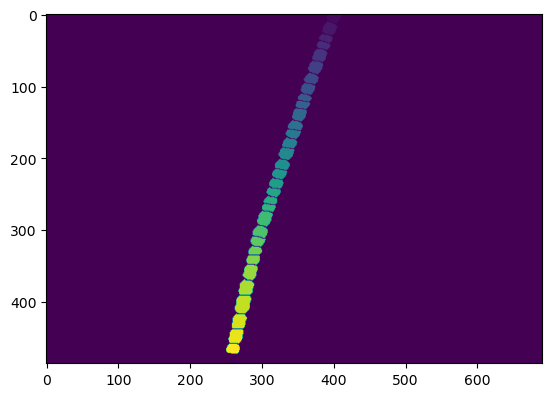

In [15]:
plt.imshow(test_img)

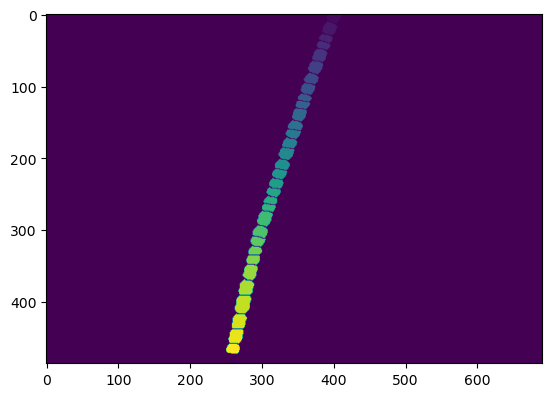

In [16]:
plt.imshow(output)

In [17]:
output[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [18]:
testimg = tifffile.imread('/Users/bebr1814/projects/anabaena/scratch_data/bulk_training_set/20241010_001_ZMB002.03.merged_mask.tiff')
# convert to int32
testimg = testimg.astype(np.uint16)
testimg[0]

array([0, 0, 0, ..., 0, 0, 0], dtype=uint16)

In [11]:
testimg = tifffile.imread('/Users/bebr1814/projects/anabaena/scratch_data/bulk_training_set/2020.3.5_ana33047_minusn_0003_Crop_cropped.frame_79.brightfield_mask.tiff')
testimg[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,